In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import dill
import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = True
%load_ext autoreload
%autoreload 2
import pathlib
import numpy as np
import getdist
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import MixtureND
%matplotlib inline





## Make plot of FoM vs ell_max for all three probes

In [2]:
param_labels_dict = {
    'Om0': r'$\Omega_{\rm m}$',
    'Ob0': r'$\Omega_{\rm b}$',
    'H0': r'$H_0$',
    'ns': r'$n_{\rm s}$',
    'sigma8': r'$\sigma_8$',
    'theta_ej_0': r'$\theta_{\rm ej, 0}$',
    'nu_theta_ej_M': r'$\nu_{\theta_{\rm ej, M}}$',
    'nu_theta_ej_z': r'$\nu_{\theta_{\rm ej, z}}',    
    'mu_beta': r'$\mu_\beta$',
    'delta_rhogas': r'$\delta_{\rho_{\rm gas}}$',
    'gamma_rhogas': r'$\gamma_{\rho_{\rm gas}}$',
    'alpha_nt': r'$\alpha_{\rm nt}$',
    'beta_fshmr': r'$\beta_{\rm fshmr}$',
    'gamma_fshmr': r'$\gamma_{\rm fshmr}$',
    'Bcut_Nsat': r'$B_{\rm cut}^{\rm N_{sat}}$',
    'betacut_Nsat': r'$\beta_{\rm cut}^{\rm N_{sat}}$',
    'betasat_Nsat': r'$\beta_{\rm sat}^{\rm N_{sat}}$',
    'siglogMstar_Ncen': r'$\sigma_{\log M_\star}^{\rm N_{cen}}$',
    'alphasat_Nsat': r'$\alpha_{\rm sat}^{\rm N_{sat}}$',
    'A_IA': r'$A_{\rm IA}$',
    'eta_IA': r'$\eta_{\rm IA}$',
    'mult_shear_bias_bin1': r'$m_1$',
    'mult_shear_bias_bin2': r'$m_2$',
    'mult_shear_bias_bin3': r'$m_3$',
    'mult_shear_bias_bin4': r'$m_4$',
    'mult_shear_bias_bin5': r'$m_5$',
    'Delta_z_bias_bin1': r'$\Delta z_1$',
    'Delta_z_bias_bin2': r'$\Delta z_2$',
    'Delta_z_bias_bin3': r'$\Delta z_3$',
    'Delta_z_bias_bin4': r'$\Delta z_4$',
    'Delta_z_bias_bin5': r'$\Delta z_5$'
}



In [3]:
settings = {'ignore_rows': 0.0, 'smooth_scale_1D': 0.3, 'smooth_scale_2D': 0.3}
def get_FoM(fname, chain_label=None):
    df = dill.load(open(fname, 'rb'))
    F_all = df['F_all']
    sim_params_dict = df['sim_params_dict']
    other_params_dict = df['other_params_dict']

    # cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
    cosmo_params_vary_names_all = df['cosmo_params_vary_names_all']

    cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
    for jp in range(len(cosmo_params_vary_names_all)):
        cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]


    # sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','alpha_nt', 'beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'siglogMstar_Ncen', 'alphasat_Nsat']
    sims_params_vary_names_all = df['sims_params_vary_names_all']


    sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
    for jp in range(len(sims_params_vary_names_all)):
        sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]


    # IA_params_vary_names_all = ['A_IA', 'eta_IA']
    IA_params_vary_names_all = df['IA_params_vary_names_all']

    IA_params_fid_all = np.zeros(len(IA_params_vary_names_all))
    for jp in range(len(IA_params_vary_names_all)):
        IA_params_fid_all[jp] = other_params_dict[IA_params_vary_names_all[jp]]


    # mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
    mult_shear_vary_names = df['mult_shear_vary_names']
    mz_params_fid_all = np.zeros(len(mult_shear_vary_names))

    # Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']
    Delta_shear_vary_names = df['Delta_shear_vary_names']
    dz_params_fid_all = np.zeros(len(mult_shear_vary_names))

    param_names_all = np.concatenate([cosmo_params_vary_names_all, sims_params_vary_names_all, IA_params_vary_names_all, mult_shear_vary_names, Delta_shear_vary_names])
    param_labels_all = []
    for pname in param_names_all:
        param_labels_all.append(param_labels_dict[pname])

    fid_params_all = np.concatenate([cosmo_params_fid_all, sims_params_fid_all, IA_params_fid_all, mz_params_fid_all, dz_params_fid_all])

    cov = np.linalg.inv(F_all)
    mean = fid_params_all
    # get samples from this multi dimensional gaussian
    samples = np.random.multivariate_normal(mean, cov, 100000)

    chain = MCSamples(samples=samples, names=param_names_all,
                            labels=param_labels_all, name_tag=chain_label,settings=settings)
    
    FoM_Om_sig8 = 1/np.sqrt(np.linalg.det(chain.getCov(pars=[0,4])))

    return FoM_Om_sig8, chain



In [44]:
ldir = '/mnt/home/spandey/ceph/GODMAX/results/pge/fisher_mats_v2/'
ell_max_all = [500, 1000, 2000, 4000, 8000]
# ell_max_all = [500, 1000, 2000, 4000]
FoM_all_probes_all = []
chain_all_probes_all = []
for ell_max in ell_max_all:
    # FoM_Om_sig8, chain = get_FoM(ldir + 'Fisher_final_pro
    FoM_Om_sig8, chain = get_FoM(ldir + f'Fisher_final_probes_ky_kk_gg_gy_gk_ge_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))
    # print(FoM_Om_sig8)
    FoM_all_probes_all.append(FoM_Om_sig8)


FoM_all_notSZ = []
# chain_all_probes_all = []
for ell_max in ell_max_all:
    # FoM_Om_sig8, chain = get_FoM(ldir + 'Fisher_final_pro
    FoM_Om_sig8, chain = get_FoM(ldir + f'Fisher_final_probes_kk_gg_gk_ge_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))
    # print(FoM_Om_sig8)
    FoM_all_notSZ.append(FoM_Om_sig8)


FoM_all_noshear = []
# chain_all_probes_all = []
for ell_max in ell_max_all:
    # FoM_Om_sig8, chain = get_FoM(ldir + 'Fisher_final_pro
    FoM_Om_sig8, chain = get_FoM(ldir + f'Fisher_final_probes_gg_gk_ge_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))
    # print(FoM_Om_sig8)
    FoM_all_noshear.append(FoM_Om_sig8)



FoM_all_notSZ_nokSZ = []
# chain_all_probes_all = []
for ell_max in ell_max_all:
    # FoM_Om_sig8, chain = get_FoM(ldir + 'Fisher_final_pro
    FoM_Om_sig8, chain = get_FoM(ldir + f'Fisher_final_probes_kk_gg_gk_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))
    # print(FoM_Om_sig8)
    FoM_all_notSZ_nokSZ.append(FoM_Om_sig8)


ell_max_all2 = [500, 1000, 2000, 4000, 8000]
FoM_all_noshear_nokSZ = []
# chain_all_probes_all = []
for ell_max in ell_max_all2:
    # FoM_Om_sig8, chain = get_FoM(ldir + 'Fisher_final_pro
    FoM_Om_sig8, chain = get_FoM(ldir + f'Fisher_final_probes_gg_gk_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))
    # print(FoM_Om_sig8)
    FoM_all_noshear_nokSZ.append(FoM_Om_sig8)


/tmp/ipykernel_908807/2434732305.py:51: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, cov, 100000)


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [45]:
FoM_all_noshear_nokSZ, FoM_all_noshear, FoM_all_notSZ_nokSZ


([435.5301063170279,
  900.064885150897,
  1086.7735609363017,
  1451.5267073265336,
  2405.3249545239432],
 [915.5393368343092,
  1386.8810724959171,
  2072.3060755067527,
  3215.2734132331657,
  4573.243728051899],
 [1149.2679647988637,
  1764.8895942331544,
  2799.215326319882,
  4633.819178286969,
  7089.199850221332])

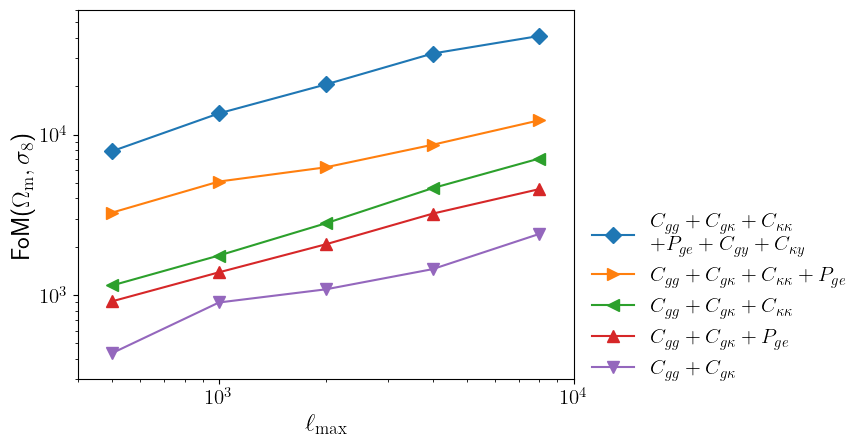

In [47]:
pl.figure()

pl.plot(ell_max_all, FoM_all_probes_all, 'D-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$' +  '\n' + r'$+ P_{ge} + C_{gy} + C_{\kappa y}$')
pl.plot(ell_max_all, FoM_all_notSZ, '>-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa} + P_{ge}$')
pl.plot(ell_max_all, FoM_all_notSZ_nokSZ, '<-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$')
pl.plot(ell_max_all, FoM_all_noshear, '^-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + P_{ge}$')


pl.plot(ell_max_all2, FoM_all_noshear_nokSZ, 'v-', ms=8.0, label=r'$C_{gg} + C_{g \kappa}$')


pl.xscale('log')
pl.yscale('log')
pl.legend(frameon=False, fontsize=15, bbox_to_anchor=(1, 0.5))
pl.ylim(3e2, 6e4)
pl.xlim(400, 1e4)
pl.tick_params(axis='both', which='major', labelsize=15)
pl.tick_params(axis='both', which='minor', labelsize=15)
pl.xlabel(r'$\ell_{\rm max}$', fontsize=18)
pl.ylabel(r'FoM($\Omega_{\rm m}, \sigma_8$)', fontsize=18)
pl.savefig('FoM_vs_ellmax_v3.pdf', bbox_inches='tight')




Text(0, 0.5, 'FoM($\\Omega_{\\rm m}, \\sigma_8$)')

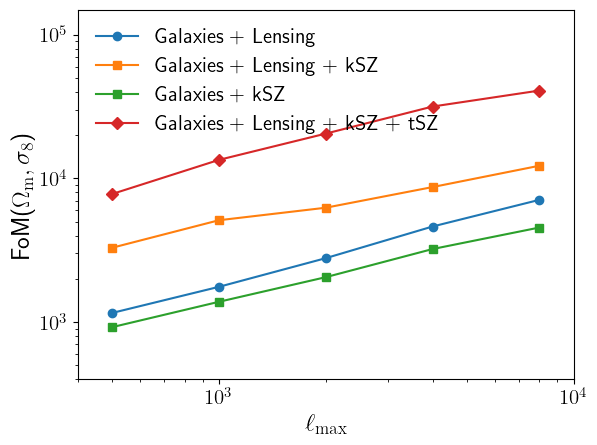

In [13]:
pl.figure()
pl.plot(ell_max_all, FoM_all_notSZ_nokSZ, 'o-', label='Galaxies + Lensing')
pl.plot(ell_max_all, FoM_all_notSZ, 's-', label='Galaxies + Lensing + kSZ')
pl.plot(ell_max_all, FoM_all_noshear, 's-', label='Galaxies + kSZ')
pl.plot(ell_max_all, FoM_all_probes_all, 'D-', label='Galaxies + Lensing + kSZ + tSZ')
pl.xscale('log')
pl.yscale('log')
pl.legend(frameon=False, fontsize=15)
pl.ylim(4e2, 1.5e5)
pl.xlim(400, 1e4)
pl.tick_params(axis='both', which='major', labelsize=15)
pl.tick_params(axis='both', which='minor', labelsize=15)
pl.xlabel(r'$\ell_{\rm max}$', fontsize=18)
pl.ylabel(r'FoM($\Omega_{\rm m}, \sigma_8$)', fontsize=18)
# pl.savefig('FoM_vs_ellmax.pdf', bbox_inches='tight')




In [36]:
ell_max = 4000

_, chain_all = get_FoM(ldir + f'Fisher_final_probes_ky_kk_gg_gy_gk_ge_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))

_, chain_wkSZ = get_FoM(ldir + f'Fisher_final_probes_kk_gg_gk_ge_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))

_, chain_nokSZ = get_FoM(ldir + f'Fisher_final_probes_kk_gg_gk_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))



/tmp/ipykernel_1280769/2434732305.py:51: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, cov, 100000)


Removed no burn in
Removed no burn in
Removed no burn in


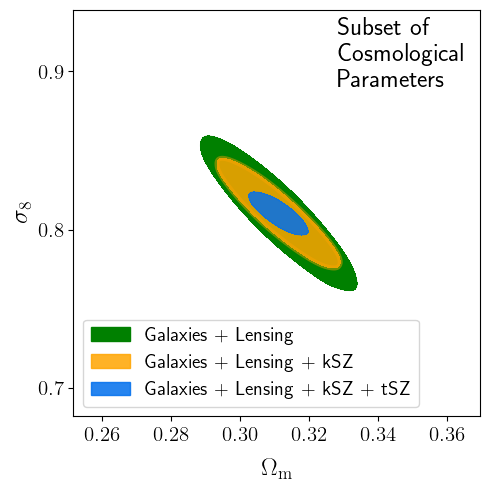

In [45]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
g.plot_2d(all_samples,'Om0', 'sigma8', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] )
        #   ,lims=[0.284, 0.346, 0.77, 0.9])  
g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ', r'Galaxies + Lensing + kSZ + tSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Cosmological' + '\n' + 'Parameters', x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
g.export(fname = 'cosmo_directcal.pdf')
# g.export(fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/plots/Om_sig8_forecast_all_FINALSET.pdf')



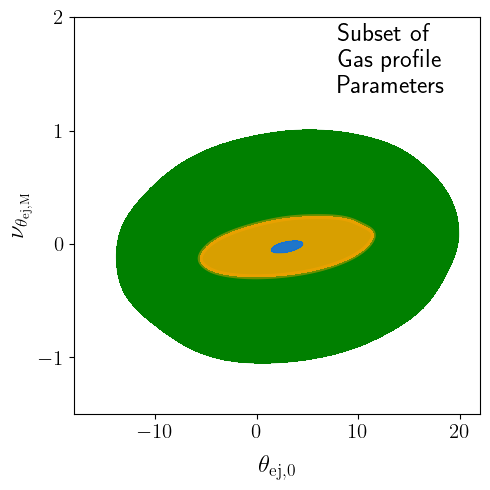

In [47]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
g.plot_2d(all_samples,'theta_ej_0', 'nu_theta_ej_M', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] 
           ,lims=[-18, 22, -1.5, 2])  
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Gas profile   ' + '\n' + 'Parameters',  x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
g.export(fname = 'gas_prof_directcal.pdf')



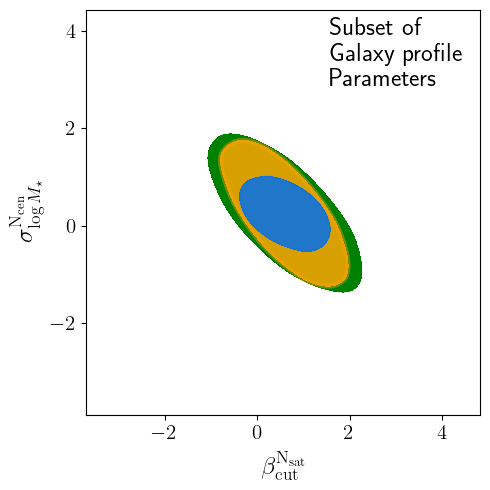

In [48]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
g.plot_2d(all_samples,'betacut_Nsat', 'siglogMstar_Ncen', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] )  
g.add_text('Subset of' + '\n' 'Galaxy profile   ' + '\n' + 'Parameters',  x=0.62, y=0.89, fontsize=18, horizontalalignment='left')        
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.export(fname = 'gal_prof_directcal.pdf')


In [21]:
ldir = '/mnt/home/spandey/ceph/GODMAX/results/pge/fisher_biases_v2/'
# Fisher_final_probes_kk_gg_gk_ellmax_2000
ell_max_all = [500, 1000, 2000, 4000, 8000]
# FoM_all_probes_all = []
# chain_all_probes_all = []
Om_true = 0.3111
sig8_true = 0.8102
S8_true = sig8_true * (Om_true/0.3)**0.5
bias_S8_all = []
for ell_max in ell_max_all:
    # FoM_Om_sig8, chain = get_FoM(ldir + 'Fisher_final_pro
    df = dill.load(open(ldir + f'Fisher_final_probes_kk_gg_gk_ellmax_{ell_max}.pk','rb'))
    # print(df.keys())
    # print(df['bias'])
    # biasval = np.abs((df['mean_S8_c1'] - df['mean_S8_c2'])/df['sig_S8_c1'])
    biasval = np.abs((S8_true - df['mean_S8_c2'])/df['sig_S8_c1'])    
    bias_S8_all.append(biasval[0,0])
    # print()
    # FoM_Om_sig8, chain = get_FoM(ldir + f'Fisher_biases_Om_S8_probes_kk_kg_gg_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))
    # FoM_all_probes_all.append(FoM_Om_sig8)
# /mnt/home/spandey/ceph/GODMAX/results/pge/fisher_biases_v2/Fisher_final_probes_kk_gg_gk_ellmax_500.pk
# /mnt/home/spandey/ceph/GODMAX/results/pge/fisher_biases_v2/Fisher_final_probes_kk_kg_gg_ellmax_500.pk




In [18]:
# bias_S8_all
df.keys()



dict_keys(['F_all', 'F_cosmo', 'F_sims', 'F_IA', 'F_mz', 'F_dz', 'dmu_cosmo_all', 'dmu_sims_all', 'dmu_IA_all', 'dmu_mult_shear_all', 'dmu_bias_Deltaz_all', 'dmu_all', 'Cl_all_nfw', 'Cl_all_fid', 'delta_Cl_all', 'delta_params', 'sigma_params', 'bias_sigma_params', 'param_vary_name_all', 'cosmo_params_vary_names_all', 'sims_params_vary_names_all', 'IA_params_vary_names_all', 'mult_shear_vary_names', 'Delta_shear_vary_names', 'sim_params_dict', 'halo_params_dict', 'analysis_dict', 'other_params_dict', 'samples_ws8_c1', 'param_names_all_ws8_c1', 'param_labels_all_ws8_c1', 'samples_ws8_c2', 'param_names_all_ws8_c2', 'param_labels_all_ws8_c2', 'sig_S8_c1', 'sig_S8_c2', 'mean_S8_c1', 'mean_S8_c2', 'bias'])

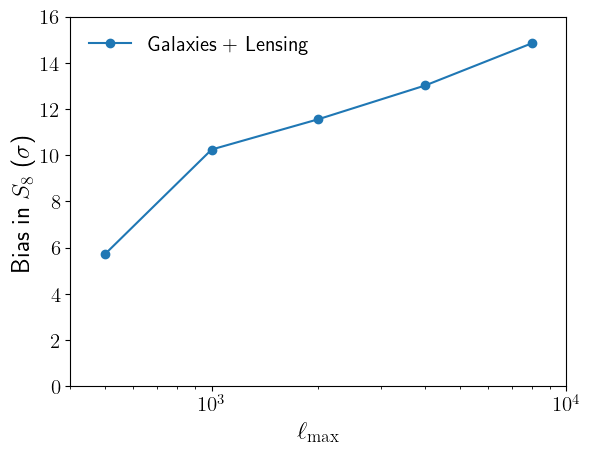

In [24]:
pl.figure()
pl.plot(ell_max_all, bias_S8_all, 'o-', label='Galaxies + Lensing')
# pl.plot(ell_max_all, FoM_all_notSZ, 's-', label='Galaxies + Lensing + kSZ')
# pl.plot(ell_max_all, FoM_all_probes_all, 'D-', label='Galaxies + Lensing + kSZ + tSZ')
pl.xscale('log')
# pl.yscale('log')
pl.legend(frameon=False, fontsize=15)
# pl.ylim(1e3, 1.5e5)
pl.ylim(0,16)
pl.xlim(400, 10000)
pl.tick_params(axis='both', which='major', labelsize=15)
pl.tick_params(axis='both', which='minor', labelsize=15)
pl.xlabel(r'$\ell_{\rm max}$', fontsize=18)
pl.ylabel(r'Bias in $S_8$ ($\sigma$)', fontsize=18)
pl.savefig('FoB_S8_vs_ellmax.pdf', bbox_inches='tight')






In [43]:
settings = {'ignore_rows': 0.0, 'smooth_scale_1D': 0.3, 'smooth_scale_2D': 0.3}

ell_max = 500
df = dill.load(open(ldir + f'Fisher_final_probes_kk_gg_gk_ellmax_{ell_max}.pk','rb'))
samples_ws8_c1 = df['samples_ws8_c1']
param_names_all_ws8_c1 = df['param_names_all_ws8_c1']
param_labels_all_ws8_c1 = df['param_labels_all_ws8_c1']

samples_ws8_c2 = df['samples_ws8_c2']
param_names_all_ws8_c2 = df['param_names_all_ws8_c2']
param_labels_all_ws8_c2 = df['param_labels_all_ws8_c2']

chain1 = MCSamples(samples=samples_ws8_c1, names=param_names_all_ws8_c1,
                        labels=param_labels_all_ws8_c1, name_tag='chain1',settings=settings)

chain2_ellmax_500 = MCSamples(samples=samples_ws8_c2, names=param_names_all_ws8_c2,
                        labels=param_labels_all_ws8_c2, name_tag='chain2',settings=settings)



Removed no burn in
Removed no burn in


In [44]:
settings = {'ignore_rows': 0.0, 'smooth_scale_1D': 0.3, 'smooth_scale_2D': 0.3}

ell_max = 2000
df = dill.load(open(ldir + f'Fisher_final_probes_kk_gg_gk_ellmax_{ell_max}.pk','rb'))
samples_ws8_c1 = df['samples_ws8_c1']
param_names_all_ws8_c1 = df['param_names_all_ws8_c1']
param_labels_all_ws8_c1 = df['param_labels_all_ws8_c1']

samples_ws8_c2 = df['samples_ws8_c2']
param_names_all_ws8_c2 = df['param_names_all_ws8_c2']
param_labels_all_ws8_c2 = df['param_labels_all_ws8_c2']

chain1 = MCSamples(samples=samples_ws8_c1, names=param_names_all_ws8_c1,
                        labels=param_labels_all_ws8_c1, name_tag='chain1',settings=settings)

chain2_ellmax_2000 = MCSamples(samples=samples_ws8_c2, names=param_names_all_ws8_c2,
                        labels=param_labels_all_ws8_c2, name_tag='chain2',settings=settings)



Removed no burn in
Removed no burn in


In [46]:
settings = {'ignore_rows': 0.0, 'smooth_scale_1D': 0.3, 'smooth_scale_2D': 0.3}

ell_max = 8000
df = dill.load(open(ldir + f'Fisher_final_probes_kk_gg_gk_ellmax_{ell_max}.pk','rb'))
samples_ws8_c1 = df['samples_ws8_c1']
param_names_all_ws8_c1 = df['param_names_all_ws8_c1']
param_labels_all_ws8_c1 = df['param_labels_all_ws8_c1']

samples_ws8_c2 = df['samples_ws8_c2']
param_names_all_ws8_c2 = df['param_names_all_ws8_c2']
param_labels_all_ws8_c2 = df['param_labels_all_ws8_c2']

chain1 = MCSamples(samples=samples_ws8_c1, names=param_names_all_ws8_c1,
                        labels=param_labels_all_ws8_c1, name_tag='chain1',settings=settings)

chain2_ellmax_4000 = MCSamples(samples=samples_ws8_c2, names=param_names_all_ws8_c2,
                        labels=param_labels_all_ws8_c2, name_tag='chain2',settings=settings)



Removed no burn in
Removed no burn in


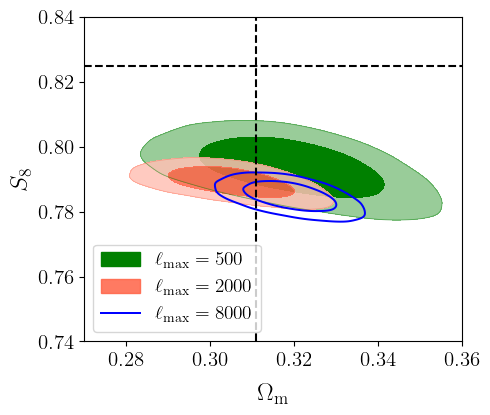

In [52]:
g = plots.getSinglePlotter(width_inch=5, ratio=0.85)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':0.1,'color':'green'},{'lw':0.1,'color':'tomato'}]
all_samples = [chain2_ellmax_500, chain2_ellmax_2000, chain2_ellmax_4000]
g.plot_2d(all_samples,'Om0', 'S8', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, False], contour_colors = ['green','tomato']
          ,ls=['','','','',''] ,lims=[0.27, 0.36, 0.74, 0.84])  
g.add_x_marker(0.3111, color='black', lw=1.5)
g.add_y_marker(S8_true, color='black', lw=1.5)
g.add_legend([r'$\ell_{\rm max}=500$', r'$\ell_{\rm max}=2000$', r'$\ell_{\rm max}=8000$'], legend_loc='lower left', fontsize=14)
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
# g.add_text('Cosmological' + '\n' + 'Parameters', x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
g.export(fname = 'bias_cosmo.pdf')
# g.export(fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/plots/Om_sig8_forecast_all_FINALSET.pdf')





## Get the samples out of the fisher contours

In [9]:
# %matplotlib inline
bias_S8_all.shape

AttributeError: 'list' object has no attribute 'shape'